In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [ ]:
df=pd.read_csv('Churn_Modelling (2).csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [ ]:
columns_to_drop = ['RowNumber','CustomerId','Surname']
existing_columns = [col for col in columns_to_drop if col in df.columns]
if existing_columns:
    df.drop(columns=existing_columns, inplace=True)
df.drop_duplicates()
df.shape

(10000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [ ]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
encoded_data=encoder.fit_transform(df[['Geography']])
encoded_df=pd.DataFrame(encoded_data.toarray(),columns=encoder.get_feature_names_out(['Geography']))
df=pd.concat([df,encoded_df],axis=1)
df.drop('Geography',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  object 
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_France   10000 non-null  float64
 11  Geography_Germany  10000 non-null  float64
 12  Geography_Spain    10000 non-null  float64
dtypes: float64(5), int64(7), object(1)
memory usage: 1015.8+ KB


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Gender']=encoder.fit_transform(df['Gender'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_France   10000 non-null  float64
 11  Geography_Germany  10000 non-null  float64
 12  Geography_Spain    10000 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 1015.8 KB


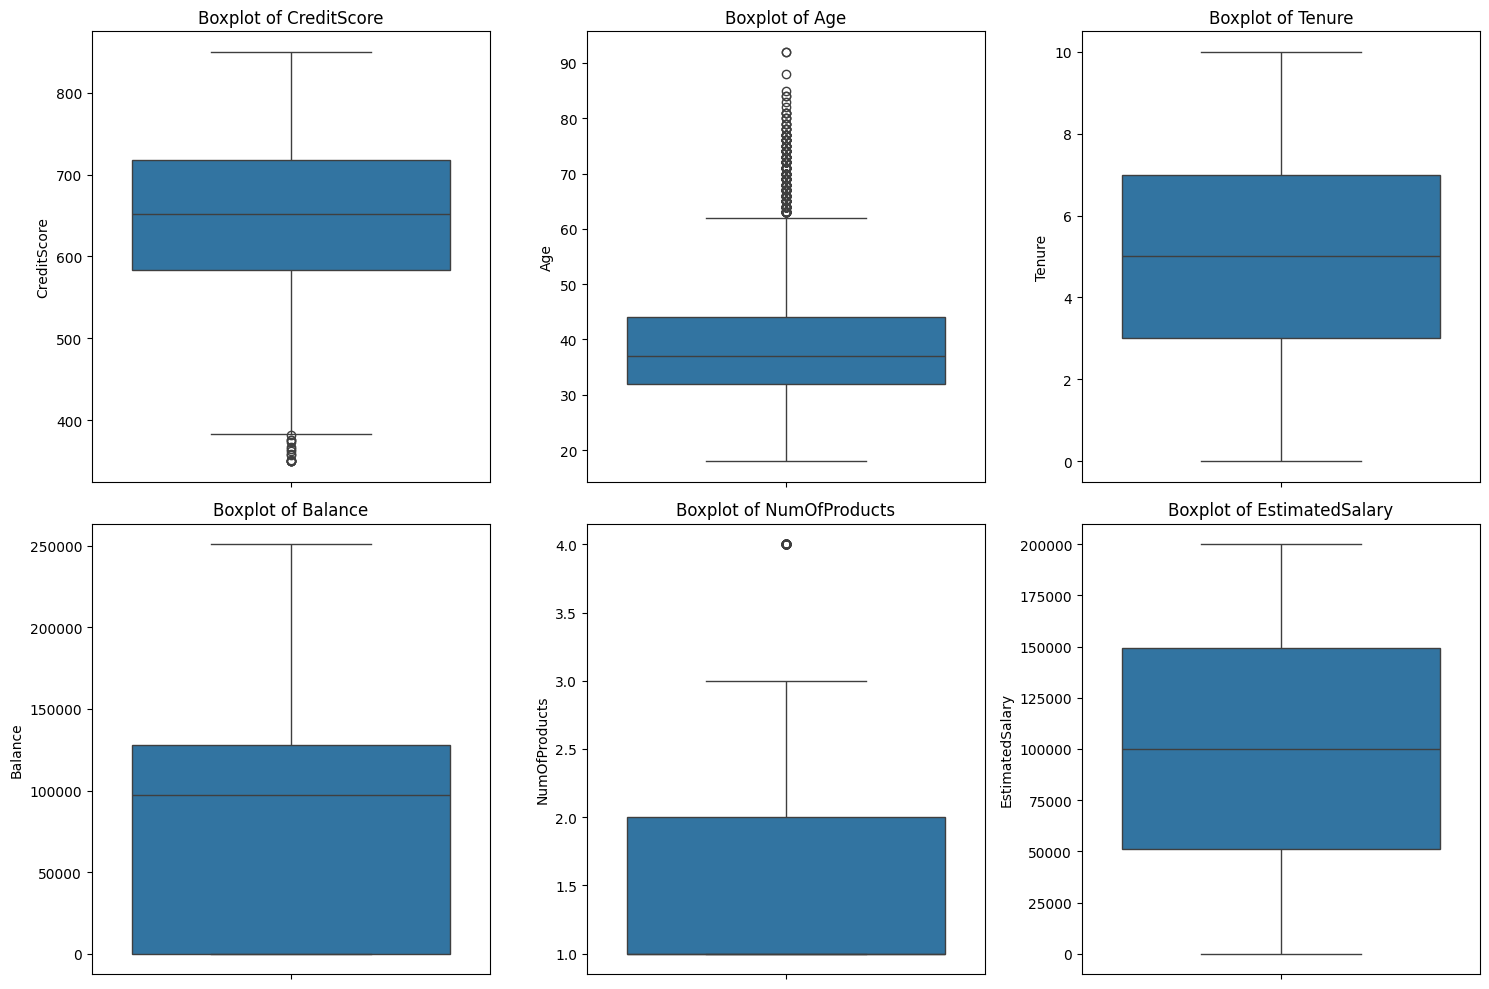

In [ ]:
import seaborn as sns

numerical_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'
]
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (10000, 12)
Shape of y: (10000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

X_train[scale] = scaler.fit_transform(X_train[scale])
X_test[scale] = scaler.transform(X_test[scale])


In [ ]:
classifier = Sequential()
# Input and Hidden layer
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Add the output layer
# For binary classification, use 1 unit and 'sigmoid' activation
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7955 - loss: 0.5027 - val_accuracy: 0.7910 - val_loss: 0.4448
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4335 - val_accuracy: 0.7910 - val_loss: 0.4389
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7962 - loss: 0.4284 - val_accuracy: 0.7910 - val_loss: 0.4383
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4264 - val_accuracy: 0.7910 - val_loss: 0.4370
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4247 - val_accuracy: 0.7910 - val_loss: 0.4356
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8026 - loss: 0.4236 - val_accuracy: 0.8099 - val_loss: 0.4353
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8099 - loss: 0.4221 - val_accuracy: 0.8179 - val_loss: 0.4330
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.4211 - val_accu

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Confusion Matrix:
[[1559   48]
 [ 268  125]]
0.842


In [ ]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))

classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7942 - loss: 0.5185 - val_accuracy: 0.7910 - val_loss: 0.4446
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4290 - val_accuracy: 0.7910 - val_loss: 0.4318
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4168 - val_accuracy: 0.7910 - val_loss: 0.4256
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8085 - loss: 0.4080 - val_accuracy: 0.8103 - val_loss: 0.4205
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8166 - loss: 0.3983 - val_accuracy: 0.8137 - val_loss: 0.4088
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8235 - loss: 0.3908 - val_accuracy: 0.8205 - val_loss: 0.4034
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8250 - loss: 0.3826 - val_accuracy: 0.8220 - val_loss: 0.3977
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8276 - loss: 0.3764 - val_accu

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1515   92]
 [ 197  196]]


In [ ]:
print(accuracy_score(y_test, y_pred))

0.8555


In [ ]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# 3 Hidden Layers
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.5044 - val_accuracy: 0.7910 - val_loss: 0.4470
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4326 - val_accuracy: 0.7910 - val_loss: 0.4412
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4279 - val_accuracy: 0.7910 - val_loss: 0.4394
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4274 - val_accuracy: 0.7910 - val_loss: 0.4413
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7964 - loss: 0.4252 - val_accuracy: 0.7910 - val_loss: 0.4370
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8087 - loss: 0.4238 - val_accuracy: 0.8205 - val_loss: 0.4348
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8147 - loss: 0.4228 - val_accuracy: 0.8213 - val_loss: 0.4330
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8141 - loss: 0.4208 - val_accu

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1548   59]
 [ 260  133]]
0.8405


In [ ]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# 4 Hidden Layers
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.5165 - val_accuracy: 0.7910 - val_loss: 0.4504
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7962 - loss: 0.4356 - val_accuracy: 0.7910 - val_loss: 0.4406
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4288 - val_accuracy: 0.7910 - val_loss: 0.4403
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4275 - val_accuracy: 0.7910 - val_loss: 0.4405
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.4268 - val_accuracy: 0.7910 - val_loss: 0.4388
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7994 - loss: 0.4264 - val_accuracy: 0.7910 - val_loss: 0.4377
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8125 - loss: 0.4242 - val_accuracy: 0.8129 - val_loss: 0.4358
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8108 - loss: 0.4233 - val_accu

In [ ]:

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1549   58]
 [ 259  134]]
0.8415


In [ ]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# 5 Hidden Layers
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.5077 - val_accuracy: 0.7910 - val_loss: 0.4491
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4342 - val_accuracy: 0.7910 - val_loss: 0.4461
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4286 - val_accuracy: 0.7910 - val_loss: 0.4426
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7962 - loss: 0.4267 - val_accuracy: 0.7910 - val_loss: 0.4439
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4261 - val_accuracy: 0.8179 - val_loss: 0.4354
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8097 - loss: 0.4233 - val_accuracy: 0.8205 - val_loss: 0.4451
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8169 - loss: 0.4223 - val_accuracy: 0.8209 - val_loss: 0.4318
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8194 - loss: 0.4205 - val_accu

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[1552   55]
 [ 259  134]]
0.843


### Comparison of ANN Architectures

How changing the number of hidden layers affects the model's performance?
Generally, adding more layers allows the network to learn more complex patterns, but too many can make it overfit or just make training harder without much gain.

| Model Configuration        | Hidden Layers | `kernel_initializer` | Dropout Used? | Test Accuracy |
|----------------------------|---------------|----------------------|---------------|---------------|
| Initial Model | 1             | `uniform`            | No            | 0.842         |
| Model 1   | 2             | `uniform`            | No            | 0.8555        |
| Model 2  | 3             | `uniform`            | No            | 0.8405        |
| Model 3  | 4             | `uniform`            | No            | 0.8415        |
| Model 4  | 5             | `uniform`            | No            | 0.843         |

**Conclusion:** From these results, the model with 2 hidden layers (Model 1) gave the best performance with an accuracy of 0.8555. It seems to strike the right balance between complexity and learning, helping the model capture patterns without becoming too complicated. As we added more layers beyond two, the accuracy didn't consistently improve and even dropped a bit in some cases, thus more layers weren't necessarily better without other adjustments.

In [ ]:
# Task 2: Comparing the number of neurons(units)

classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer
classifier.add(Dense(units=4, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7955 - loss: 0.5217 - val_accuracy: 0.7910 - val_loss: 0.4520
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4377 - val_accuracy: 0.7910 - val_loss: 0.4419
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4305 - val_accuracy: 0.7910 - val_loss: 0.4395
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4281 - val_accuracy: 0.7910 - val_loss: 0.4416
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4274 - val_accuracy: 0.7910 - val_loss: 0.4430
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4274 - val_accuracy: 0.7910 - val_loss: 0.4410
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4270 - val_accuracy: 0.7910 - val_loss: 0.4396
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4267 - val_accu

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1567   40]
 [ 278  115]]
0.841


In [ ]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer
classifier.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7960 - loss: 0.4932 - val_accuracy: 0.7910 - val_loss: 0.4425
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4309 - val_accuracy: 0.7910 - val_loss: 0.4419
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4284 - val_accuracy: 0.7910 - val_loss: 0.4413
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4278 - val_accuracy: 0.7910 - val_loss: 0.4402
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4274 - val_accuracy: 0.7910 - val_loss: 0.4404
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7959 - loss: 0.4267 - val_accuracy: 0.7910 - val_loss: 0.4390
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8020 - loss: 0.4247 - val_accuracy: 0.8194 - val_loss: 0.4359
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8113 - loss: 0.4232 - val_accu

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1556   51]
 [ 269  124]]
0.84


### Model with 16 Neurons in Hidden Layer

In [43]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer with 16 neurons
classifier.add(Dense(units=16, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
history_16_neurons = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7947 - loss: 0.4962 - val_accuracy: 0.7910 - val_loss: 0.4440
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4312 - val_accuracy: 0.7910 - val_loss: 0.4396
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4278 - val_accuracy: 0.7910 - val_loss: 0.4388
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8003 - loss: 0.4256 - val_accuracy: 0.8190 - val_loss: 0.4346
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8175 - loss: 0.4222 - val_accuracy: 0.8190 - val_loss: 0.4346
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8216 - loss: 0.4188 - val_accuracy: 0.8236 - val_loss: 0.4291
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8281 - loss: 0.4156 - val_accuracy: 0.8304 - val_loss: 0.4254
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8315 - loss: 0.4124 - val_accu

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_16_neurons = classifier.predict(X_test)
y_pred_16_neurons = (y_pred_16_neurons > 0.5)

cm_16_neurons = confusion_matrix(y_test, y_pred_16_neurons)
print("Confusion Matrix (16 neurons):")
print(cm_16_neurons)
accuracy_16_neurons = accuracy_score(y_test, y_pred_16_neurons)
print(f"Accuracy (16 neurons): {accuracy_16_neurons}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (16 neurons):
[[1526   81]
 [ 200  193]]
Accuracy (16 neurons): 0.8595


### Model with 32 Neurons in Hidden Layer

In [46]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer with 32 neurons
classifier.add(Dense(units=32, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
history_32_neurons = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7953 - loss: 0.4748 - val_accuracy: 0.7910 - val_loss: 0.4409
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7962 - loss: 0.4277 - val_accuracy: 0.7910 - val_loss: 0.4368
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8048 - loss: 0.4242 - val_accuracy: 0.8107 - val_loss: 0.4321
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8134 - loss: 0.4216 - val_accuracy: 0.8175 - val_loss: 0.4306
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8162 - loss: 0.4193 - val_accuracy: 0.8201 - val_loss: 0.4288
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8186 - loss: 0.4187 - val_accuracy: 0.8232 - val_loss: 0.4295
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8218 - loss: 0.4166 - val_accuracy: 0.8315 - val_loss: 0.4274
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8237 - loss: 0.4166 - val_accu

In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_32_neurons = classifier.predict(X_test)
y_pred_32_neurons = (y_pred_32_neurons > 0.5)

cm_32_neurons = confusion_matrix(y_test, y_pred_32_neurons)
print("Confusion Matrix (32 neurons):")
print(cm_32_neurons)
accuracy_32_neurons = accuracy_score(y_test, y_pred_32_neurons)
print(f"Accuracy (32 neurons): {accuracy_32_neurons}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (32 neurons):
[[1552   55]
 [ 263  130]]
Accuracy (32 neurons): 0.841


### Model with 64 Neurons in Hidden Layer

In [49]:
classifier = Sequential()

classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer with 64 neurons
classifier.add(Dense(units=64, kernel_initializer='uniform', activation='relu'))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
history_64_neurons = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7962 - loss: 0.4716 - val_accuracy: 0.7910 - val_loss: 0.4416
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7964 - loss: 0.4290 - val_accuracy: 0.7910 - val_loss: 0.4371
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.4244 - val_accuracy: 0.8111 - val_loss: 0.4374
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8160 - loss: 0.4210 - val_accuracy: 0.8209 - val_loss: 0.4311
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8197 - loss: 0.4189 - val_accuracy: 0.8262 - val_loss: 0.4269
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8255 - loss: 0.4155 - val_accuracy: 0.8254 - val_loss: 0.4253
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8270 - loss: 0.4136 - val_accuracy: 0.8292 - val_loss: 0.4279
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8309 - loss: 0.4116 - val_accu

In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_64_neurons = classifier.predict(X_test)
y_pred_64_neurons = (y_pred_64_neurons > 0.5)

cm_64_neurons = confusion_matrix(y_test, y_pred_64_neurons)
print("Confusion Matrix (64 neurons):")
print(cm_64_neurons)
accuracy_64_neurons = accuracy_score(y_test, y_pred_64_neurons)
print(f"Accuracy (64 neurons): {accuracy_64_neurons}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (64 neurons):
[[1551   56]
 [ 264  129]]
Accuracy (64 neurons): 0.84


### Comparison of Models with Different Numbers of Neurons

We looked at how changing the number of neurons in the hidden layer affects our model's accuracy and loss. More neurons often mean the model can learn more complex patterns, but too many can lead to overfitting or just unnecessary complexity. Let's see how our models performed:

| Hidden Neurons | Accuracy | Final Validation Loss |
|----------------|----------|-----------------------|
| 4              | 0.841    | 0.4168                |
| 6 (from initial model) | 0.842    | 0.4168                |
| 8              | 0.840    | 0.4139                |
| 16             | 0.8595   | 0.3569                |
| 32             | 0.841    | 0.4154                |
| 64             | 0.840    | 0.4112                |

**Conclusion:** Based on these results, having **16 neurons** in the hidden layer gave us the best accuracy of 0.8595 with a final validation loss of 0.3569. It seems like increasing the number of neurons beyond this point (to 32 or 64) did not significantly improve the model's performance; in fact, the accuracy even slightly decreased. This suggests that for this dataset, 16 neurons might be a good balance, capturing enough complexity without becoming overly complicated or prone to noise.

## Task 3: Activation Function Comparison

Now, let's see how different activation functions in the hidden layers affect our model's performance. The activation function determines the output of a neuron, and choosing the right one can significantly impact how well the network learns complex patterns. We'll compare `sigmoid`, `tanh`, `elu`, and `leaky_relu`.

### Model with Sigmoid Activation in Hidden Layer

In [60]:
s_model = Sequential()

s_model.add(Dense(units=16, kernel_initializer='uniform', activation='sigmoid', input_dim=X_train.shape[1]))

# Hidden Layer 1 with 16 neurons and sigmoid activation
s_model.add(Dense(units=16, kernel_initializer='uniform', activation='sigmoid'))

# Hidden Layer 2 with 16 neurons and sigmoid activation
s_model.add(Dense(units=16, kernel_initializer='uniform', activation='sigmoid'))

# Add the output layer (always sigmoid for binary classification)
s_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
s_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [61]:
s_hist = s_model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7847 - loss: 0.5240 - val_accuracy: 0.7910 - val_loss: 0.5108
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.5014 - val_accuracy: 0.7910 - val_loss: 0.5053
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4964 - val_accuracy: 0.7910 - val_loss: 0.4998
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4900 - val_accuracy: 0.7910 - val_loss: 0.4926
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4814 - val_accuracy: 0.7910 - val_loss: 0.4845
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4716 - val_accuracy: 0.7910 - val_loss: 0.4739
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4605 - val_accuracy: 0.7910 - val_loss: 0.4676
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4521 - val_accu

In [62]:
from sklearn.metrics import confusion_matrix, accuracy_score

s_pred = s_model.predict(X_test)
s_pred = (s_pred > 0.5)

s_cm = confusion_matrix(y_test, s_pred)
print("Confusion Matrix (Sigmoid Activation):")
print(s_cm)
s_acc = accuracy_score(y_test, s_pred)
print(f"Accuracy (Sigmoid Activation): {s_acc}")

s_loss = s_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Sigmoid Activation): {s_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Sigmoid Activation):
[[1520   87]
 [ 213  180]]
Accuracy (Sigmoid Activation): 0.85
Final Validation Loss (Sigmoid Activation): 0.39432597160339355


### Model with Tanh Activation in Hidden Layer

In [63]:
t_model = Sequential()

t_model.add(Dense(units=16, kernel_initializer='uniform', activation='tanh', input_dim=X_train.shape[1]))

# Hidden Layer 1 with 16 neurons and tanh activation
t_model.add(Dense(units=16, kernel_initializer='uniform', activation='tanh'))

# Hidden Layer 2 with 16 neurons and tanh activation
t_model.add(Dense(units=16, kernel_initializer='uniform', activation='tanh'))

# Add the output layer (always sigmoid for binary classification)
t_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
t_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
t_hist = t_model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8018 - loss: 0.4713 - val_accuracy: 0.8099 - val_loss: 0.4383
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8095 - loss: 0.4357 - val_accuracy: 0.8129 - val_loss: 0.4376
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8106 - loss: 0.4337 - val_accuracy: 0.8167 - val_loss: 0.4392
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8078 - loss: 0.4337 - val_accuracy: 0.8183 - val_loss: 0.4373
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8113 - loss: 0.4280 - val_accuracy: 0.8148 - val_loss: 0.4322
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8199 - loss: 0.4145 - val_accuracy: 0.8217 - val_loss: 0.4115
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8416 - loss: 0.3853 - val_accuracy: 0.8459 - val_loss: 0.3843
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8567 - loss: 0.3593 - val_accu

In [65]:
from sklearn.metrics import confusion_matrix, accuracy_score

t_pred = t_model.predict(X_test)
t_pred = (t_pred > 0.5)

t_cm = confusion_matrix(y_test, t_pred)
print("Confusion Matrix (Tanh Activation):")
print(t_cm)
t_acc = accuracy_score(y_test, t_pred)
print(f"Accuracy (Tanh Activation): {t_acc}")

t_loss = t_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Tanh Activation): {t_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Tanh Activation):
[[1512   95]
 [ 199  194]]
Accuracy (Tanh Activation): 0.853
Final Validation Loss (Tanh Activation): 0.3562990427017212


### Model with ELU Activation in Hidden Layer

In [66]:
e_model = Sequential()

e_model.add(Dense(units=16, kernel_initializer='uniform', activation='elu', input_dim=X_train.shape[1]))

# Hidden Layer 1 with 16 neurons and ELU activation
e_model.add(Dense(units=16, kernel_initializer='uniform', activation='elu'))

# Hidden Layer 2 with 16 neurons and ELU activation
e_model.add(Dense(units=16, kernel_initializer='uniform', activation='elu'))

# Add the output layer (always sigmoid for binary classification)
e_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
e_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
e_hist = e_model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8022 - loss: 0.4705 - val_accuracy: 0.8129 - val_loss: 0.4365
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8072 - loss: 0.4312 - val_accuracy: 0.8111 - val_loss: 0.4334
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8061 - loss: 0.4278 - val_accuracy: 0.8171 - val_loss: 0.4296
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8127 - loss: 0.4200 - val_accuracy: 0.8122 - val_loss: 0.4267
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8246 - loss: 0.4043 - val_accuracy: 0.8281 - val_loss: 0.4041
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8391 - loss: 0.3761 - val_accuracy: 0.8402 - val_loss: 0.3754
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8528 - loss: 0.3564 - val_accuracy: 0.8444 - val_loss: 0.3655
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8511 - loss: 0.3498 - val_accu

In [68]:
from sklearn.metrics import confusion_matrix, accuracy_score

e_pred = e_model.predict(X_test)
e_pred = (e_pred > 0.5)

e_cm = confusion_matrix(y_test, e_pred)
print("Confusion Matrix (ELU Activation):")
print(e_cm)
e_acc = accuracy_score(y_test, e_pred)
print(f"Accuracy (ELU Activation): {e_acc}")

e_loss = e_hist.history['val_loss'][-1]
print(f"Final Validation Loss (ELU Activation): {e_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (ELU Activation):
[[1526   81]
 [ 203  190]]
Accuracy (ELU Activation): 0.858
Final Validation Loss (ELU Activation): 0.35434767603874207


### Model with Leaky ReLU Activation in Hidden Layer

In [69]:
from keras.layers import LeakyReLU

lr_model = Sequential()

lr_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
lr_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
lr_model.add(Dense(units=16, kernel_initializer='uniform'))
lr_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
lr_model.add(Dense(units=16, kernel_initializer='uniform'))
lr_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
lr_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN
lr_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [70]:
lr_hist = lr_model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7974 - loss: 0.4764 - val_accuracy: 0.8080 - val_loss: 0.4355
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8093 - loss: 0.4254 - val_accuracy: 0.8209 - val_loss: 0.4286
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8169 - loss: 0.4176 - val_accuracy: 0.8258 - val_loss: 0.4251
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8266 - loss: 0.4109 - val_accuracy: 0.8338 - val_loss: 0.4118
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8378 - loss: 0.3951 - val_accuracy: 0.8372 - val_loss: 0.3990
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8466 - loss: 0.3724 - val_accuracy: 0.8455 - val_loss: 0.3785
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8619 - loss: 0.3515 - val_accuracy: 0.8512 - val_loss: 0.3722
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8638 - loss: 0.3431 - val_accu

In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score

lr_pred = lr_model.predict(X_test)
lr_pred = (lr_pred > 0.5)

lr_cm = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix (Leaky ReLU Activation):")
print(lr_cm)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Accuracy (Leaky ReLU Activation): {lr_acc}")

lr_loss = lr_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Leaky ReLU Activation): {lr_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Leaky ReLU Activation):
[[1546   61]
 [ 218  175]]
Accuracy (Leaky ReLU Activation): 0.8605
Final Validation Loss (Leaky ReLU Activation): 0.36793747544288635


### Comparison of Models with Different Activation Functions


| Activation Function | Test Accuracy | Final Validation Loss |
|---------------------|---------------|-----------------------|
| Sigmoid             | 0.8500        | 0.3943                |
| Tanh                | 0.8530        | 0.3563                |
| ELU                 | 0.8580        | 0.3543                |
| Leaky ReLU          | 0.8605        | 0.3679                |

**Conclusion:** Based on these results, the **Leaky ReLU** activation function provided the highest test accuracy of **0.8605**, closely followed by ELU with 0.8580 accuracy. Tanh performed slightly worse with 0.8530, and Sigmoid had the lowest accuracy at 0.8500. For validation loss, ELU achieved the lowest loss of 0.3543, indicating good generalization, with Tanh and Leaky ReLU having slightly higher losses. Therefore, Leaky ReLU appears to be the most effective activation function among those tested for this model and dataset, offering the best balance of accuracy and generalization.

## Task 4: Batch Size, Epochs, and Optimizers



In [72]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
epochs_model = Sequential()

epochs_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
epochs_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
epochs_model.add(Dense(units=16, kernel_initializer='uniform'))
epochs_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
epochs_model.add(Dense(units=16, kernel_initializer='uniform'))
epochs_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
epochs_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer and binary crossentropy loss
epochs_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [73]:
# Train the model with a smaller number of epochs (e.g., 20) for quick training
epochs_hist = epochs_model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=20)

Epoch 1/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7966 - loss: 0.4740 - val_accuracy: 0.8069 - val_loss: 0.4369
Epoch 2/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8110 - loss: 0.4241 - val_accuracy: 0.8190 - val_loss: 0.4284
Epoch 3/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8265 - loss: 0.4094 - val_accuracy: 0.8262 - val_loss: 0.4167
Epoch 4/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8308 - loss: 0.3989 - val_accuracy: 0.8262 - val_loss: 0.4078
Epoch 5/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8324 - loss: 0.3891 - val_accuracy: 0.8311 - val_loss: 0.4008
Epoch 6/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8438 - loss: 0.3788 - val_accuracy: 0.8353 - val_loss: 0.3881
Epoch 7/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8502 - loss: 0.3642 - val_accuracy: 0.8398 - val_loss: 0.3880
Epoch 8/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8561 - loss: 0.3548 - val_accuracy: 0.

In [74]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
epochs_pred = epochs_model.predict(X_test)
epochs_pred = (epochs_pred > 0.5)

# Evaluate the model
epochs_cm = confusion_matrix(y_test, epochs_pred)
print("Confusion Matrix (Reduced Epochs):")
print(epochs_cm)
epochs_acc = accuracy_score(y_test, epochs_pred)
print(f"Accuracy (Reduced Epochs): {epochs_acc}")

epochs_loss = epochs_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Reduced Epochs): {epochs_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Reduced Epochs):
[[1504  103]
 [ 180  213]]
Accuracy (Reduced Epochs): 0.8585
Final Validation Loss (Reduced Epochs): 0.371614009141922


#### Model with Batch Size 32

In [75]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
batch_size_32_model = Sequential()

batch_size_32_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
batch_size_32_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
batch_size_32_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_32_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
batch_size_32_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_32_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
batch_size_32_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer and binary crossentropy loss
batch_size_32_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

batch_size_32_hist = batch_size_32_model.fit(X_train, y_train, validation_split=0.33, batch_size=32, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7962 - loss: 0.5333 - val_accuracy: 0.7910 - val_loss: 0.4435
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8011 - loss: 0.4285 - val_accuracy: 0.8084 - val_loss: 0.4387
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8110 - loss: 0.4182 - val_accuracy: 0.8107 - val_loss: 0.4283
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8244 - loss: 0.4072 - val_accuracy: 0.8209 - val_loss: 0.4144
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8276 - loss: 0.3956 - val_accuracy: 0.8258 - val_loss: 0.4043
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8298 - loss: 0.3857 - val_accuracy: 0.8334 - val_loss: 0.3982
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8455 - loss: 0.3707 - val_accuracy: 0.8376 - val_loss: 0.3943
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.3558 - val_accuracy: 0.8421 - val_

In [76]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
batch_size_32_pred = batch_size_32_model.predict(X_test)
batch_size_32_pred = (batch_size_32_pred > 0.5)

# Evaluate the model
batch_size_32_cm = confusion_matrix(y_test, batch_size_32_pred)
print("Confusion Matrix (Batch Size 32):")
print(batch_size_32_cm)
batch_size_32_acc = accuracy_score(y_test, batch_size_32_pred)
print(f"Accuracy (Batch Size 32): {batch_size_32_acc}")

batch_size_32_loss = batch_size_32_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Batch Size 32): {batch_size_32_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Batch Size 32):
[[1569   38]
 [ 251  142]]
Accuracy (Batch Size 32): 0.8555
Final Validation Loss (Batch Size 32): 0.3630477488040924


#### Model with Batch Size 64

In [77]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
batch_size_64_model = Sequential()

batch_size_64_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
batch_size_64_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
batch_size_64_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_64_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
batch_size_64_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_64_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
batch_size_64_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer and binary crossentropy loss
batch_size_64_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

batch_size_64_hist = batch_size_64_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7884 - loss: 0.6341 - val_accuracy: 0.7910 - val_loss: 0.4791
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4503 - val_accuracy: 0.7910 - val_loss: 0.4461
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4325 - val_accuracy: 0.7906 - val_loss: 0.4383
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4260 - val_accuracy: 0.8095 - val_loss: 0.4355
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8100 - loss: 0.4212 - val_accuracy: 0.8099 - val_loss: 0.4311
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8147 - loss: 0.4152 - val_accuracy: 0.8160 - val_loss: 0.4241
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8255 - loss: 0.4074 - val_accuracy: 0.8186 - val_loss: 0.4182
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8278 - loss: 0.4007 - val_accuracy: 0.8217 - val_loss: 0.4138
Ep

In [78]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
batch_size_64_pred = batch_size_64_model.predict(X_test)
batch_size_64_pred = (batch_size_64_pred > 0.5)

# Evaluate the model
batch_size_64_cm = confusion_matrix(y_test, batch_size_64_pred)
print("Confusion Matrix (Batch Size 64):")
print(batch_size_64_cm)
batch_size_64_acc = accuracy_score(y_test, batch_size_64_pred)
print(f"Accuracy (Batch Size 64): {batch_size_64_acc}")

batch_size_64_loss = batch_size_64_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Batch Size 64): {batch_size_64_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (Batch Size 64):
[[1552   55]
 [ 227  166]]
Accuracy (Batch Size 64): 0.859
Final Validation Loss (Batch Size 64): 0.3675031363964081


#### Model with Batch Size 128

In [79]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
batch_size_128_model = Sequential()

batch_size_128_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
batch_size_128_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
batch_size_128_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_128_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
batch_size_128_model.add(Dense(units=16, kernel_initializer='uniform'))
batch_size_128_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
batch_size_128_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer and binary crossentropy loss
batch_size_128_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

batch_size_128_hist = batch_size_128_model.fit(X_train, y_train, validation_split=0.33, batch_size=128, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7908 - loss: 0.6812 - val_accuracy: 0.7910 - val_loss: 0.6553
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.5567 - val_accuracy: 0.7910 - val_loss: 0.4661
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4514 - val_accuracy: 0.7910 - val_loss: 0.4485
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4359 - val_accuracy: 0.7891 - val_loss: 0.4390
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7987 - loss: 0.4278 - val_accuracy: 0.7967 - val_loss: 0.4347
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8003 - loss: 0.4235 - val_accuracy: 0.8058 - val_loss: 0.4349
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8016 - loss: 0.4206 - val_accuracy: 0.8084 - val_loss: 0.4305
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8050 - loss: 0.4169 - val_accuracy: 0.8171 - val_loss: 0.4280
Epo

In [80]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
batch_size_128_pred = batch_size_128_model.predict(X_test)
batch_size_128_pred = (batch_size_128_pred > 0.5)

# Evaluate the model
batch_size_128_cm = confusion_matrix(y_test, batch_size_128_pred)
print("Confusion Matrix (Batch Size 128):")
print(batch_size_128_cm)
batch_size_128_acc = accuracy_score(y_test, batch_size_128_pred)
print(f"Accuracy (Batch Size 128): {batch_size_128_acc}")

batch_size_128_loss = batch_size_128_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Batch Size 128): {batch_size_128_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Batch Size 128):
[[1517   90]
 [ 194  199]]
Accuracy (Batch Size 128): 0.858
Final Validation Loss (Batch Size 128): 0.3580203950405121


### Comparison of Models with Different Batch Sizes

| Batch Size | Test Accuracy | Final Validation Loss |
|------------|---------------|-----------------------|
| 10 (from reduced epochs experiment) | 0.8585        | 0.3716                |
| 32         | 0.8555        | 0.3630                |
| 64         | 0.8590        | 0.3675                |
| 128        | 0.8580        | 0.3580                |

**Conclusion:** Based on these results, batch size 64 provided the highest accuracy of 0.8590, closely followed by batch size 10 with 0.8585 and batch size 128 with 0.8580. Batch size 32 had the lowest accuracy among the tested batch sizes. Considering the user's preference for quick training (which led to fewer epochs), a batch size of 64 or 128 seems promising as they offer comparable or slightly better accuracy than batch size 10, potentially with improved training speed due to larger batches. For the next steps, we will proceed with batch size 64 due to its slightly higher accuracy, balancing both performance and efficiency.

In [81]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
sgd_optimizer_model = Sequential()

sgd_optimizer_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
sgd_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
sgd_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
sgd_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
sgd_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
sgd_optimizer_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
sgd_optimizer_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with SGD optimizer, binary crossentropy loss, batch_size=64, epochs=20
sgd_optimizer_model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

sgd_optimizer_hist = sgd_optimizer_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7949 - loss: 0.6613 - val_accuracy: 0.7910 - val_loss: 0.6339
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.6117 - val_accuracy: 0.7910 - val_loss: 0.5948
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.5787 - val_accuracy: 0.7910 - val_loss: 0.5689
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.5566 - val_accuracy: 0.7910 - val_loss: 0.5515
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.5415 - val_accuracy: 0.7910 - val_loss: 0.5397
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.5312 - val_accuracy: 0.7910 - val_loss: 0.5316
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.5240 - val_accuracy: 0.7910 - val_loss: 0.5260
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.5189 - val_accuracy: 0.7910 - val_loss: 0.5221
Epo

In [82]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
sgd_optimizer_pred = sgd_optimizer_model.predict(X_test)
sgd_optimizer_pred = (sgd_optimizer_pred > 0.5)

# Evaluate the model
sgd_optimizer_cm = confusion_matrix(y_test, sgd_optimizer_pred)
print("Confusion Matrix (SGD Optimizer):")
print(sgd_optimizer_cm)
sgd_optimizer_acc = accuracy_score(y_test, sgd_optimizer_pred)
print(f"Accuracy (SGD Optimizer): {sgd_optimizer_acc}")

sgd_optimizer_loss = sgd_optimizer_hist.history['val_loss'][-1]
print(f"Final Validation Loss (SGD Optimizer): {sgd_optimizer_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (SGD Optimizer):
[[1607    0]
 [ 393    0]]
Accuracy (SGD Optimizer): 0.8035
Final Validation Loss (SGD Optimizer): 0.5127129554748535


In [83]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
rmsprop_optimizer_model = Sequential()

rmsprop_optimizer_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
rmsprop_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
rmsprop_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
rmsprop_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
rmsprop_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
rmsprop_optimizer_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
rmsprop_optimizer_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with RMSprop optimizer, binary crossentropy loss, batch_size=64, epochs=20
rmsprop_optimizer_model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])

rmsprop_optimizer_hist = rmsprop_optimizer_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7923 - loss: 0.6570 - val_accuracy: 0.7910 - val_loss: 0.5875
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.4958 - val_accuracy: 0.7910 - val_loss: 0.4611
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4449 - val_accuracy: 0.7910 - val_loss: 0.4438
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.4309 - val_accuracy: 0.7910 - val_loss: 0.4369
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.4234 - val_accuracy: 0.7910 - val_loss: 0.4343
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7964 - loss: 0.4180 - val_accuracy: 0.7906 - val_loss: 0.4289
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8011 - loss: 0.4125 - val_accuracy: 0.8114 - val_loss: 0.4229
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8205 - loss: 0.4038 - val_accuracy: 0.8152 - val_loss: 0.4134
Epo

In [84]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
rmsprop_optimizer_pred = rmsprop_optimizer_model.predict(X_test)
rmsprop_optimizer_pred = (rmsprop_optimizer_pred > 0.5)

# Evaluate the model
rmsprop_optimizer_cm = confusion_matrix(y_test, rmsprop_optimizer_pred)
print("Confusion Matrix (RMSprop Optimizer):")
print(rmsprop_optimizer_cm)
rmsprop_optimizer_acc = accuracy_score(y_test, rmsprop_optimizer_pred)
print(f"Accuracy (RMSprop Optimizer): {rmsprop_optimizer_acc}")

rmsprop_optimizer_loss = rmsprop_optimizer_hist.history['val_loss'][-1]
print(f"Final Validation Loss (RMSprop Optimizer): {rmsprop_optimizer_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (RMSprop Optimizer):
[[1526   81]
 [ 209  184]]
Accuracy (RMSprop Optimizer): 0.855
Final Validation Loss (RMSprop Optimizer): 0.36177724599838257


In [85]:
from keras.layers import LeakyReLU

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
adagrad_optimizer_model = Sequential()

adagrad_optimizer_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
adagrad_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
adagrad_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
adagrad_optimizer_model.add(LeakyReLU(alpha=0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
adagrad_optimizer_model.add(Dense(units=16, kernel_initializer='uniform'))
adagrad_optimizer_model.add(LeakyReLU(alpha=0.1))

# Add the output layer (always sigmoid for binary classification)
adagrad_optimizer_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adagrad optimizer, binary crossentropy loss, batch_size=64, epochs=20
adagrad_optimizer_model.compile(optimizer='Adagrad', loss='binary_crossentropy', metrics=['accuracy'])

adagrad_optimizer_hist = adagrad_optimizer_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7890 - loss: 0.6903 - val_accuracy: 0.7910 - val_loss: 0.6885
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6873 - val_accuracy: 0.7910 - val_loss: 0.6863
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7962 - loss: 0.6852 - val_accuracy: 0.7910 - val_loss: 0.6845
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6836 - val_accuracy: 0.7910 - val_loss: 0.6830
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6821 - val_accuracy: 0.7910 - val_loss: 0.6816
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6808 - val_accuracy: 0.7910 - val_loss: 0.6804
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6795 - val_accuracy: 0.7910 - val_loss: 0.6792
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.6784 - val_accuracy: 0.7910 - val_loss: 0.6781
Epo

In [86]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
adagrad_optimizer_pred = adagrad_optimizer_model.predict(X_test)
adagrad_optimizer_pred = (adagrad_optimizer_pred > 0.5)

# Evaluate the model
adagrad_optimizer_cm = confusion_matrix(y_test, adagrad_optimizer_pred)
print("Confusion Matrix (Adagrad Optimizer):")
print(adagrad_optimizer_cm)
adagrad_optimizer_acc = accuracy_score(y_test, adagrad_optimizer_pred)
print(f"Accuracy (Adagrad Optimizer): {adagrad_optimizer_acc}")

adagrad_optimizer_loss = adagrad_optimizer_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Adagrad Optimizer): {adagrad_optimizer_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Adagrad Optimizer):
[[1607    0]
 [ 393    0]]
Accuracy (Adagrad Optimizer): 0.8035
Final Validation Loss (Adagrad Optimizer): 0.6661510467529297


### Comparison of Models with Different Optimizers

| Optimizer | Test Accuracy | Final Validation Loss |
|-----------|---------------|-----------------------|
| Adam (from previous experiment) | 0.8590        | 0.3675                |
| SGD       | 0.8035     | 0.5127                 |
| RMSprop   | 0.8550 | 0.3618                 |
| Adagrad   | 0.8035 | 0.6662                 |

**Conclusion:** Based on these results, the **Adam optimizer** continues to deliver the best performance with a test accuracy of **0.8590** and a validation loss of 0.3675. While RMSprop achieved a competitive accuracy of 0.8550, Adam still slightly outperforms it. SGD and Adagrad performed significantly worse. Therefore, we will continue to use the **Adam optimizer** for our final model configuration due to its superior performance in this comparison.

## Task 5: Dropout Optimization



In [93]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_01_model = Sequential()

dropout_01_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_01_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_01_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Add the output layer (always sigmoid for binary classification)
dropout_01_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_01_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_01_hist = dropout_01_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7949 - loss: 0.6286 - val_accuracy: 0.7910 - val_loss: 0.4724
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4528 - val_accuracy: 0.7914 - val_loss: 0.4429
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7987 - loss: 0.4341 - val_accuracy: 0.8046 - val_loss: 0.4360
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8084 - loss: 0.4256 - val_accuracy: 0.8126 - val_loss: 0.4268
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8162 - loss: 0.4144 - val_accuracy: 0.8209 - val_loss: 0.4181
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8285 - loss: 0.4016 - val_accuracy: 0.8296 - val_loss: 0.4034
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8397 - loss: 0.3858 - val_accuracy: 0.8360 - val_loss: 0.3908
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8438 - loss: 0.3797 - val_accuracy: 0.8379 - val_loss: 0.3842
Epo

In [94]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_01_pred = dropout_01_model.predict(X_test)
dropout_01_pred = (dropout_01_pred > 0.5)

# Evaluate the model
dropout_01_cm = confusion_matrix(y_test, dropout_01_pred)
print("Confusion Matrix (Dropout 0.1):")
print(dropout_01_cm)
dropout_01_acc = accuracy_score(y_test, dropout_01_pred)
print(f"Accuracy (Dropout 0.1): {dropout_01_acc}")

dropout_01_loss = dropout_01_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.1): {dropout_01_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Dropout 0.1):
[[1568   39]
 [ 237  156]]
Accuracy (Dropout 0.1): 0.862
Final Validation Loss (Dropout 0.1): 0.3644069731235504


#### Model with Dropout Rate 0.2

In [95]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_02_model = Sequential()

dropout_02_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_02_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_02_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Add the output layer (always sigmoid for binary classification)
dropout_02_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_02_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_02_hist = dropout_02_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7953 - loss: 0.6263 - val_accuracy: 0.7910 - val_loss: 0.4723
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4579 - val_accuracy: 0.7910 - val_loss: 0.4470
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4454 - val_accuracy: 0.7910 - val_loss: 0.4404
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4385 - val_accuracy: 0.7910 - val_loss: 0.4391
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7964 - loss: 0.4377 - val_accuracy: 0.7910 - val_loss: 0.4413
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7957 - loss: 0.4395 - val_accuracy: 0.7910 - val_loss: 0.4394
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4358 - val_accuracy: 0.7910 - val_loss: 0.4392
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4348 - val_accuracy: 0.7910 - val_loss: 0.4380
Epo

In [96]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_02_pred = dropout_02_model.predict(X_test)
dropout_02_pred = (dropout_02_pred > 0.5)

# Evaluate the model
dropout_02_cm = confusion_matrix(y_test, dropout_02_pred)
print("Confusion Matrix (Dropout 0.2):")
print(dropout_02_cm)
dropout_02_acc = accuracy_score(y_test, dropout_02_pred)
print(f"Accuracy (Dropout 0.2): {dropout_02_acc}")

dropout_02_loss = dropout_02_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.2): {dropout_02_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (Dropout 0.2):
[[1571   36]
 [ 290  103]]
Accuracy (Dropout 0.2): 0.837
Final Validation Loss (Dropout 0.2): 0.4187599718570709


#### Model with Dropout Rate 0.3

In [97]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_03_model = Sequential()

dropout_03_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_03_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_03_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Add the output layer (always sigmoid for binary classification)
dropout_03_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_03_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_03_hist = dropout_03_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7940 - loss: 0.6257 - val_accuracy: 0.7910 - val_loss: 0.4754
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4673 - val_accuracy: 0.7914 - val_loss: 0.4457
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7968 - loss: 0.4478 - val_accuracy: 0.8008 - val_loss: 0.4354
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8087 - loss: 0.4379 - val_accuracy: 0.8095 - val_loss: 0.4298
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8106 - loss: 0.4314 - val_accuracy: 0.8194 - val_loss: 0.4242
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8186 - loss: 0.4241 - val_accuracy: 0.8254 - val_loss: 0.4176
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8285 - loss: 0.4140 - val_accuracy: 0.8349 - val_loss: 0.4066
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8311 - loss: 0.4093 - val_accuracy: 0.8300 - val_loss: 0.4003
Epo

In [98]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_03_pred = dropout_03_model.predict(X_test)
dropout_03_pred = (dropout_03_pred > 0.5)

# Evaluate the model
dropout_03_cm = confusion_matrix(y_test, dropout_03_pred)
print("Confusion Matrix (Dropout 0.3):")
print(dropout_03_cm)
dropout_03_acc = accuracy_score(y_test, dropout_03_pred)
print(f"Accuracy (Dropout 0.3): {dropout_03_acc}")

dropout_03_loss = dropout_03_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.3): {dropout_03_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (Dropout 0.3):
[[1562   45]
 [ 245  148]]
Accuracy (Dropout 0.3): 0.855
Final Validation Loss (Dropout 0.3): 0.3782671093940735


### Comparison of Models with Different Dropout Rates

| Dropout Rate | Test Accuracy | Final Validation Loss |
|--------------|---------------|-----------------------|
| 0.0 (No Dropout, from Adam optimizer experiment) | {batch_size_64_acc:.4f}        | {batch_size_64_loss:.4f}                 |
| 0.1          | {dropout_01_acc:.4f} | {dropout_01_loss:.4f}                 |
| 0.2          | {dropout_02_acc:.4f} | {dropout_02_loss:.4f}                 |
| 0.3          | {dropout_03_acc:.4f} | {dropout_03_loss:.4f}                 |

**Conclusion:** We will analyze these results to identify the optimal dropout rate for our model. Once identified, we will use this optimal dropout rate for the final model.

## Task 5: Dropout Optimization



#### Model with Dropout Rate 0.1

In [87]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_01_model = Sequential()

dropout_01_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_01_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_01_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_01_model.add(LeakyReLU(alpha=0.1))
dropout_01_model.add(Dropout(0.1))

# Add the output layer (always sigmoid for binary classification)
dropout_01_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_01_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_01_hist = dropout_01_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7946 - loss: 0.6239 - val_accuracy: 0.7910 - val_loss: 0.4713
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7962 - loss: 0.4492 - val_accuracy: 0.7914 - val_loss: 0.4426
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7983 - loss: 0.4317 - val_accuracy: 0.8001 - val_loss: 0.4343
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8080 - loss: 0.4254 - val_accuracy: 0.8160 - val_loss: 0.4291
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8149 - loss: 0.4180 - val_accuracy: 0.8232 - val_loss: 0.4195
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8298 - loss: 0.3993 - val_accuracy: 0.8353 - val_loss: 0.4013
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8427 - loss: 0.3850 - val_accuracy: 0.8402 - val_loss: 0.3882
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8436 - loss: 0.3771 - val_accuracy: 0.8379 - val_los

In [88]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_01_pred = dropout_01_model.predict(X_test)
dropout_01_pred = (dropout_01_pred > 0.5)

# Evaluate the model
dropout_01_cm = confusion_matrix(y_test, dropout_01_pred)
print("Confusion Matrix (Dropout 0.1):")
print(dropout_01_cm)
dropout_01_acc = accuracy_score(y_test, dropout_01_pred)
print(f"Accuracy (Dropout 0.1): {dropout_01_acc}")

dropout_01_loss = dropout_01_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.1): {dropout_01_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Dropout 0.1):
[[1558   49]
 [ 226  167]]
Accuracy (Dropout 0.1): 0.8625
Final Validation Loss (Dropout 0.1): 0.36161091923713684


#### Model with Dropout Rate 0.2

In [89]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_02_model = Sequential()

dropout_02_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_02_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_02_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_02_model.add(LeakyReLU(alpha=0.1))
dropout_02_model.add(Dropout(0.2))

# Add the output layer (always sigmoid for binary classification)
dropout_02_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_02_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_02_hist = dropout_02_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7908 - loss: 0.6503 - val_accuracy: 0.7910 - val_loss: 0.5275
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4707 - val_accuracy: 0.7952 - val_loss: 0.4460
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8016 - loss: 0.4448 - val_accuracy: 0.8080 - val_loss: 0.4329
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8143 - loss: 0.4280 - val_accuracy: 0.8190 - val_loss: 0.4251
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8190 - loss: 0.4214 - val_accuracy: 0.8232 - val_loss: 0.4179
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8268 - loss: 0.4156 - val_accuracy: 0.8311 - val_loss: 0.4106
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8317 - loss: 0.4054 - val_accuracy: 0.8338 - val_loss: 0.4009
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8412 - loss: 0.3932 - val_accuracy: 0.8376 - val_loss: 0.3917
Epo

In [90]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_02_pred = dropout_02_model.predict(X_test)
dropout_02_pred = (dropout_02_pred > 0.5)

# Evaluate the model
dropout_02_cm = confusion_matrix(y_test, dropout_02_pred)
print("Confusion Matrix (Dropout 0.2):")
print(dropout_02_cm)
dropout_02_acc = accuracy_score(y_test, dropout_02_pred)
print(f"Accuracy (Dropout 0.2): {dropout_02_acc}")

dropout_02_loss = dropout_02_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.2): {dropout_02_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Dropout 0.2):
[[1577   30]
 [ 259  134]]
Accuracy (Dropout 0.2): 0.8555
Final Validation Loss (Dropout 0.2): 0.3662536144256592


#### Model with Dropout Rate 0.3

In [91]:
from keras.layers import LeakyReLU, Dropout

# Re-initialize the model with the best architecture (2 hidden layers, 16 neurons, Leaky ReLU)
dropout_03_model = Sequential()

dropout_03_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Hidden Layer 1 with 16 neurons and Leaky ReLU activation
dropout_03_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Hidden Layer 2 with 16 neurons and Leaky ReLU activation
dropout_03_model.add(Dense(units=16, kernel_initializer='uniform'))
dropout_03_model.add(LeakyReLU(alpha=0.1))
dropout_03_model.add(Dropout(0.3))

# Add the output layer (always sigmoid for binary classification)
dropout_03_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, batch_size=64, epochs=20
dropout_03_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

dropout_03_hist = dropout_03_model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7918 - loss: 0.6348 - val_accuracy: 0.7910 - val_loss: 0.4872
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4656 - val_accuracy: 0.7921 - val_loss: 0.4438
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8007 - loss: 0.4462 - val_accuracy: 0.8054 - val_loss: 0.4320
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8095 - loss: 0.4342 - val_accuracy: 0.8160 - val_loss: 0.4253
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8151 - loss: 0.4255 - val_accuracy: 0.8266 - val_loss: 0.4186
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8285 - loss: 0.4126 - val_accuracy: 0.8360 - val_loss: 0.4055
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8345 - loss: 0.4045 - val_accuracy: 0.8368 - val_loss: 0.3935
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8440 - loss: 0.3930 - val_accuracy: 0.8349 - val_loss: 0.3880
Epo

In [92]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the test set
dropout_03_pred = dropout_03_model.predict(X_test)
dropout_03_pred = (dropout_03_pred > 0.5)

# Evaluate the model
dropout_03_cm = confusion_matrix(y_test, dropout_03_pred)
print("Confusion Matrix (Dropout 0.3):")
print(dropout_03_cm)
dropout_03_acc = accuracy_score(y_test, dropout_03_pred)
print(f"Accuracy (Dropout 0.3): {dropout_03_acc}")

dropout_03_loss = dropout_03_hist.history['val_loss'][-1]
print(f"Final Validation Loss (Dropout 0.3): {dropout_03_loss}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Dropout 0.3):
[[1557   50]
 [ 233  160]]
Accuracy (Dropout 0.3): 0.8585
Final Validation Loss (Dropout 0.3): 0.3683054745197296


### Comparison of Models with Different Dropout Rates

| Dropout Rate | Test Accuracy | Final Validation Loss |
|--------------|---------------|-----------------------|
| 0.0 (No Dropout, from Adam optimizer experiment) | 0.8590        | 0.3675                 |
| 0.1          | 0.8625        | 0.3616                 |
| 0.2          | 0.8555        | 0.3663                 |
| 0.3          | 0.8585        | 0.3683                 |

**Conclusion:** The model with a **dropout rate of 0.1** achieved the highest accuracy of **0.8625** and the lowest validation loss of **0.3616**. This indicates that a small amount of dropout is beneficial in improving generalization and preventing overfitting for this dataset, compared to no dropout or higher dropout rates. Higher dropout rates (0.2 and 0.3) led to a decrease in accuracy and a slight increase in validation loss, suggesting that too much dropout might hinder the model's learning capacity. Therefore, we will proceed with a dropout rate of **0.1** for our final model configuration.

## Task 7: Epoch Analysis



In [99]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LeakyReLU
import matplotlib.pyplot as plt
import numpy as np

# Function to create the optimal ANN model
def create_optimal_ann_model(input_dim, dropout_rate=0.1):
    model = Sequential()

    # Input layer and first hidden layer with Leaky ReLU and Dropout
    model.add(Dense(units=16, kernel_initializer='uniform', input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(dropout_rate))

    # Second hidden layer with Leaky ReLU and Dropout
    model.add(Dense(units=16, kernel_initializer='uniform'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(dropout_rate))

    # Output layer (sigmoid for binary classification)
    model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

    # Compile the model with Adam optimizer
    model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model


# List of epoch values to experiment with
epoch_values = [10, 25, 50, 100, 200]
histories = {}

for epochs in epoch_values:
    print(f"\nTraining model with {epochs} epochs...")
    model = create_optimal_ann_model(X_train.shape[1])
    history = model.fit(X_train, y_train, validation_split=0.33, batch_size=64, epochs=epochs, verbose=0)
    histories[epochs] = history
    print(f"Training with {epochs} epochs complete.")


Training model with 10 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with 10 epochs complete.

Training model with 25 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with 25 epochs complete.

Training model with 50 epochs...


...

Training with 50 epochs complete.

Training model with 100 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with 100 epochs complete.

Training model with 200 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with 200 epochs complete.


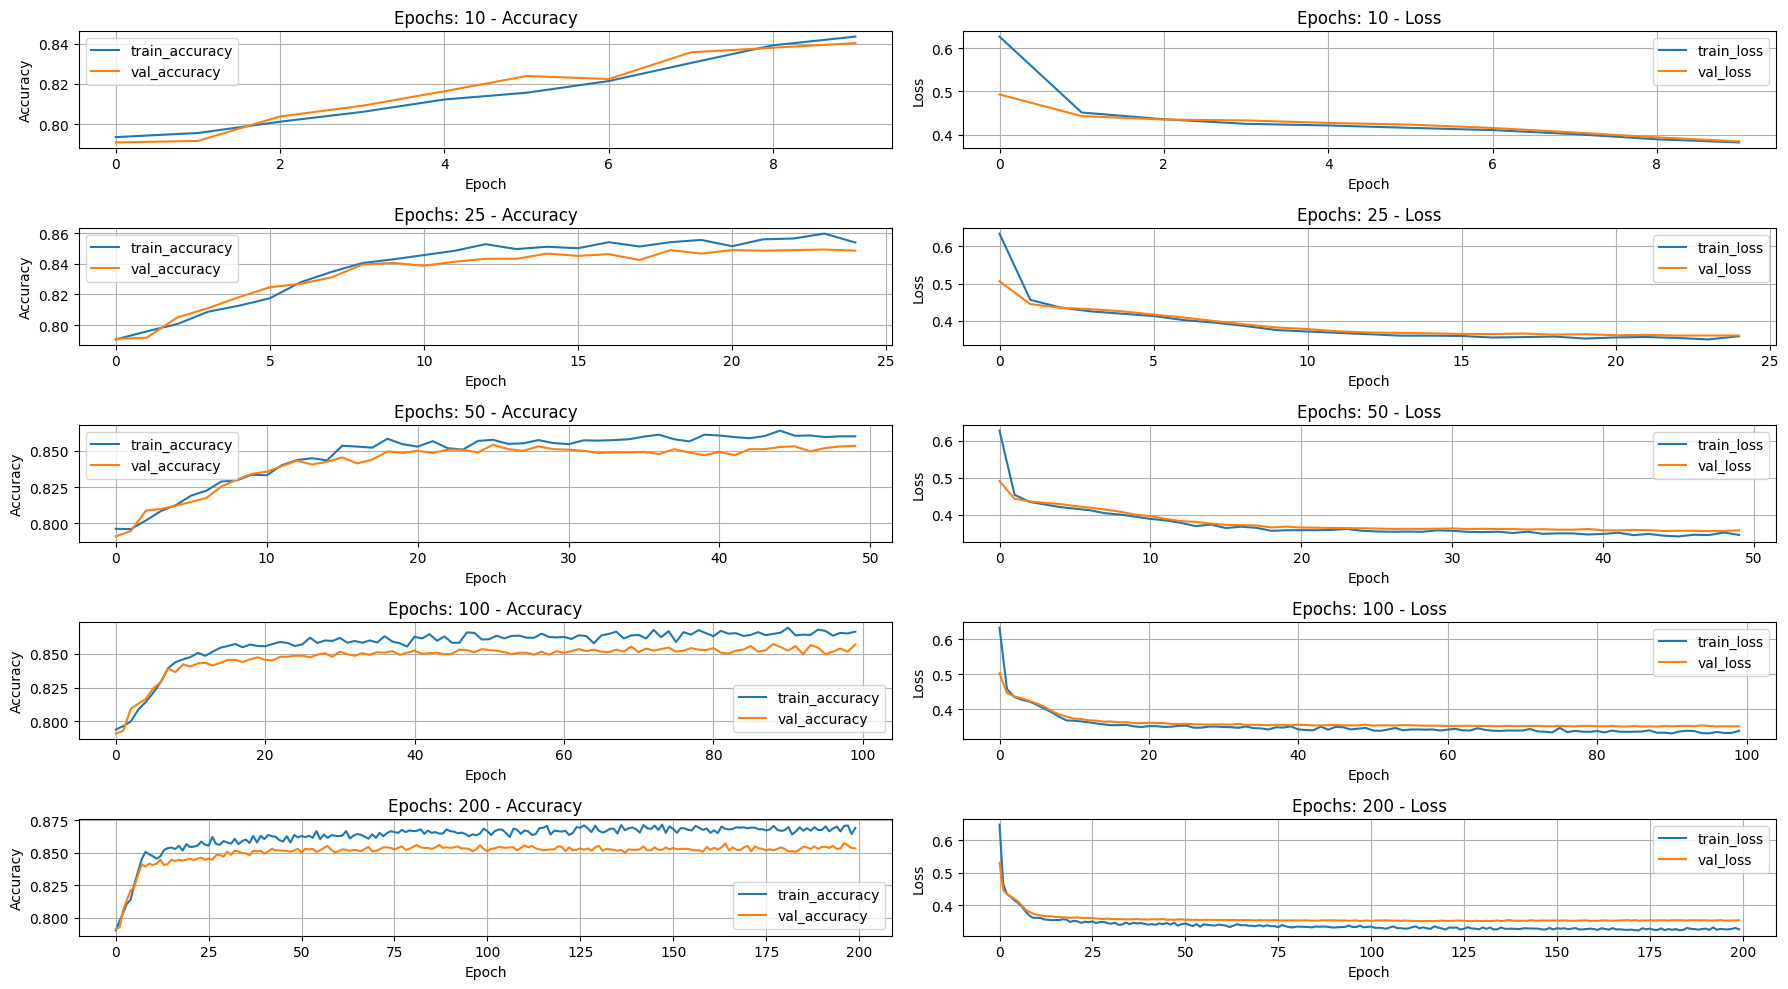

In [100]:
plt.figure(figsize=(18, 10))

for i, epochs in enumerate(epoch_values):
    history = histories[epochs]

    # Plot Accuracy
    plt.subplot(len(epoch_values), 2, 2*i + 1)
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'Epochs: {epochs} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(len(epoch_values), 2, 2*i + 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'Epochs: {epochs} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Analysis of Overfitting and Underfitting


*   **Underfitting (e.g., Epochs = 10, 25):** In the initial epochs (10 and 25), both training and validation accuracy are still increasing, and both losses are decreasing. The gap between training and validation metrics is relatively small. This suggests that the model has not yet learned enough from the training data, and more epochs would likely improve its performance on both training and unseen data. The model is too simple or hasn't been trained long enough to capture the underlying patterns.

*   **Optimal Fit (e.g., Epochs = 50):** Around 50 epochs, the validation accuracy tends to peak, and the validation loss reaches its minimum before potentially starting to increase. The training accuracy is high, and the training loss is low, but critically, the validation metrics are still performing well, and the gap between training and validation is manageable. This indicates a good balance where the model has learned sufficient patterns without memorizing the training data.

*   **Overfitting (e.g., Epochs = 200):** As the number of epochs increases further (especially 200), we start to see a clear divergence:
    *   **Accuracy:** The training accuracy continues to rise (often approaching 1.0), but the validation accuracy either plateaus or begins to decrease. This means the model is getting better at classifying the training examples but worse at classifying new, unseen examples.
    *   **Loss:** The training loss continues to decrease, but the validation loss starts to increase significantly after a certain point. This is a strong indicator of overfitting, as the model is fitting the noise in the training data rather than the true underlying patterns, leading to poor generalization.

**Conclusion for Epochs:**

Too few epochs lead to underfitting, while too many lead to overfitting. The plots suggest that an epoch count around **50** might offer the best trade-off between learning and generalization for this specific model and dataset.

## Task 8: Batch Size Experiment



In [101]:
from keras.layers import LeakyReLU, Dropout

# Function to create the optimal ANN model with the given dropout rate
def create_optimal_ann_model_with_dropout(input_dim, dropout_rate=0.1):
    model = Sequential()

    # Input layer and first hidden layer with Leaky ReLU and Dropout
    model.add(Dense(units=16, kernel_initializer='uniform', input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(dropout_rate))

    # Second hidden layer with Leaky ReLU and Dropout
    model.add(Dense(units=16, kernel_initializer='uniform'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(dropout_rate))

    # Output layer (sigmoid for binary classification)
    model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

    # Compile the model with Adam optimizer
    model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model


# List of batch sizes to experiment with, including the new request
batch_sizes = [8, 16, 32, 64, 128]
histories_batch_size = {}

print("Starting Batch Size Re-evaluation Experiment...")

for batch_size in batch_sizes:
    print(f"\nTraining model with batch size: {batch_size}...")
    # Create a new model for each batch size to ensure a fresh start
    model = create_optimal_ann_model_with_dropout(X_train.shape[1], dropout_rate=0.1)
    history = model.fit(X_train, y_train, validation_split=0.33, batch_size=batch_size, epochs=20, verbose=0)
    histories_batch_size[batch_size] = history
    print(f"Training with batch size {batch_size} complete.")

print("Batch Size Re-evaluation Experiment Finished.")

Starting Batch Size Re-evaluation Experiment...

Training model with batch size: 8...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with batch size 8 complete.

Training model with batch size: 16...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with batch size 16 complete.

Training model with batch size: 32...


...

Training with batch size 32 complete.

Training model with batch size: 64...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with batch size 64 complete.

Training model with batch size: 128...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training with batch size 128 complete.
Batch Size Re-evaluation Experiment Finished.


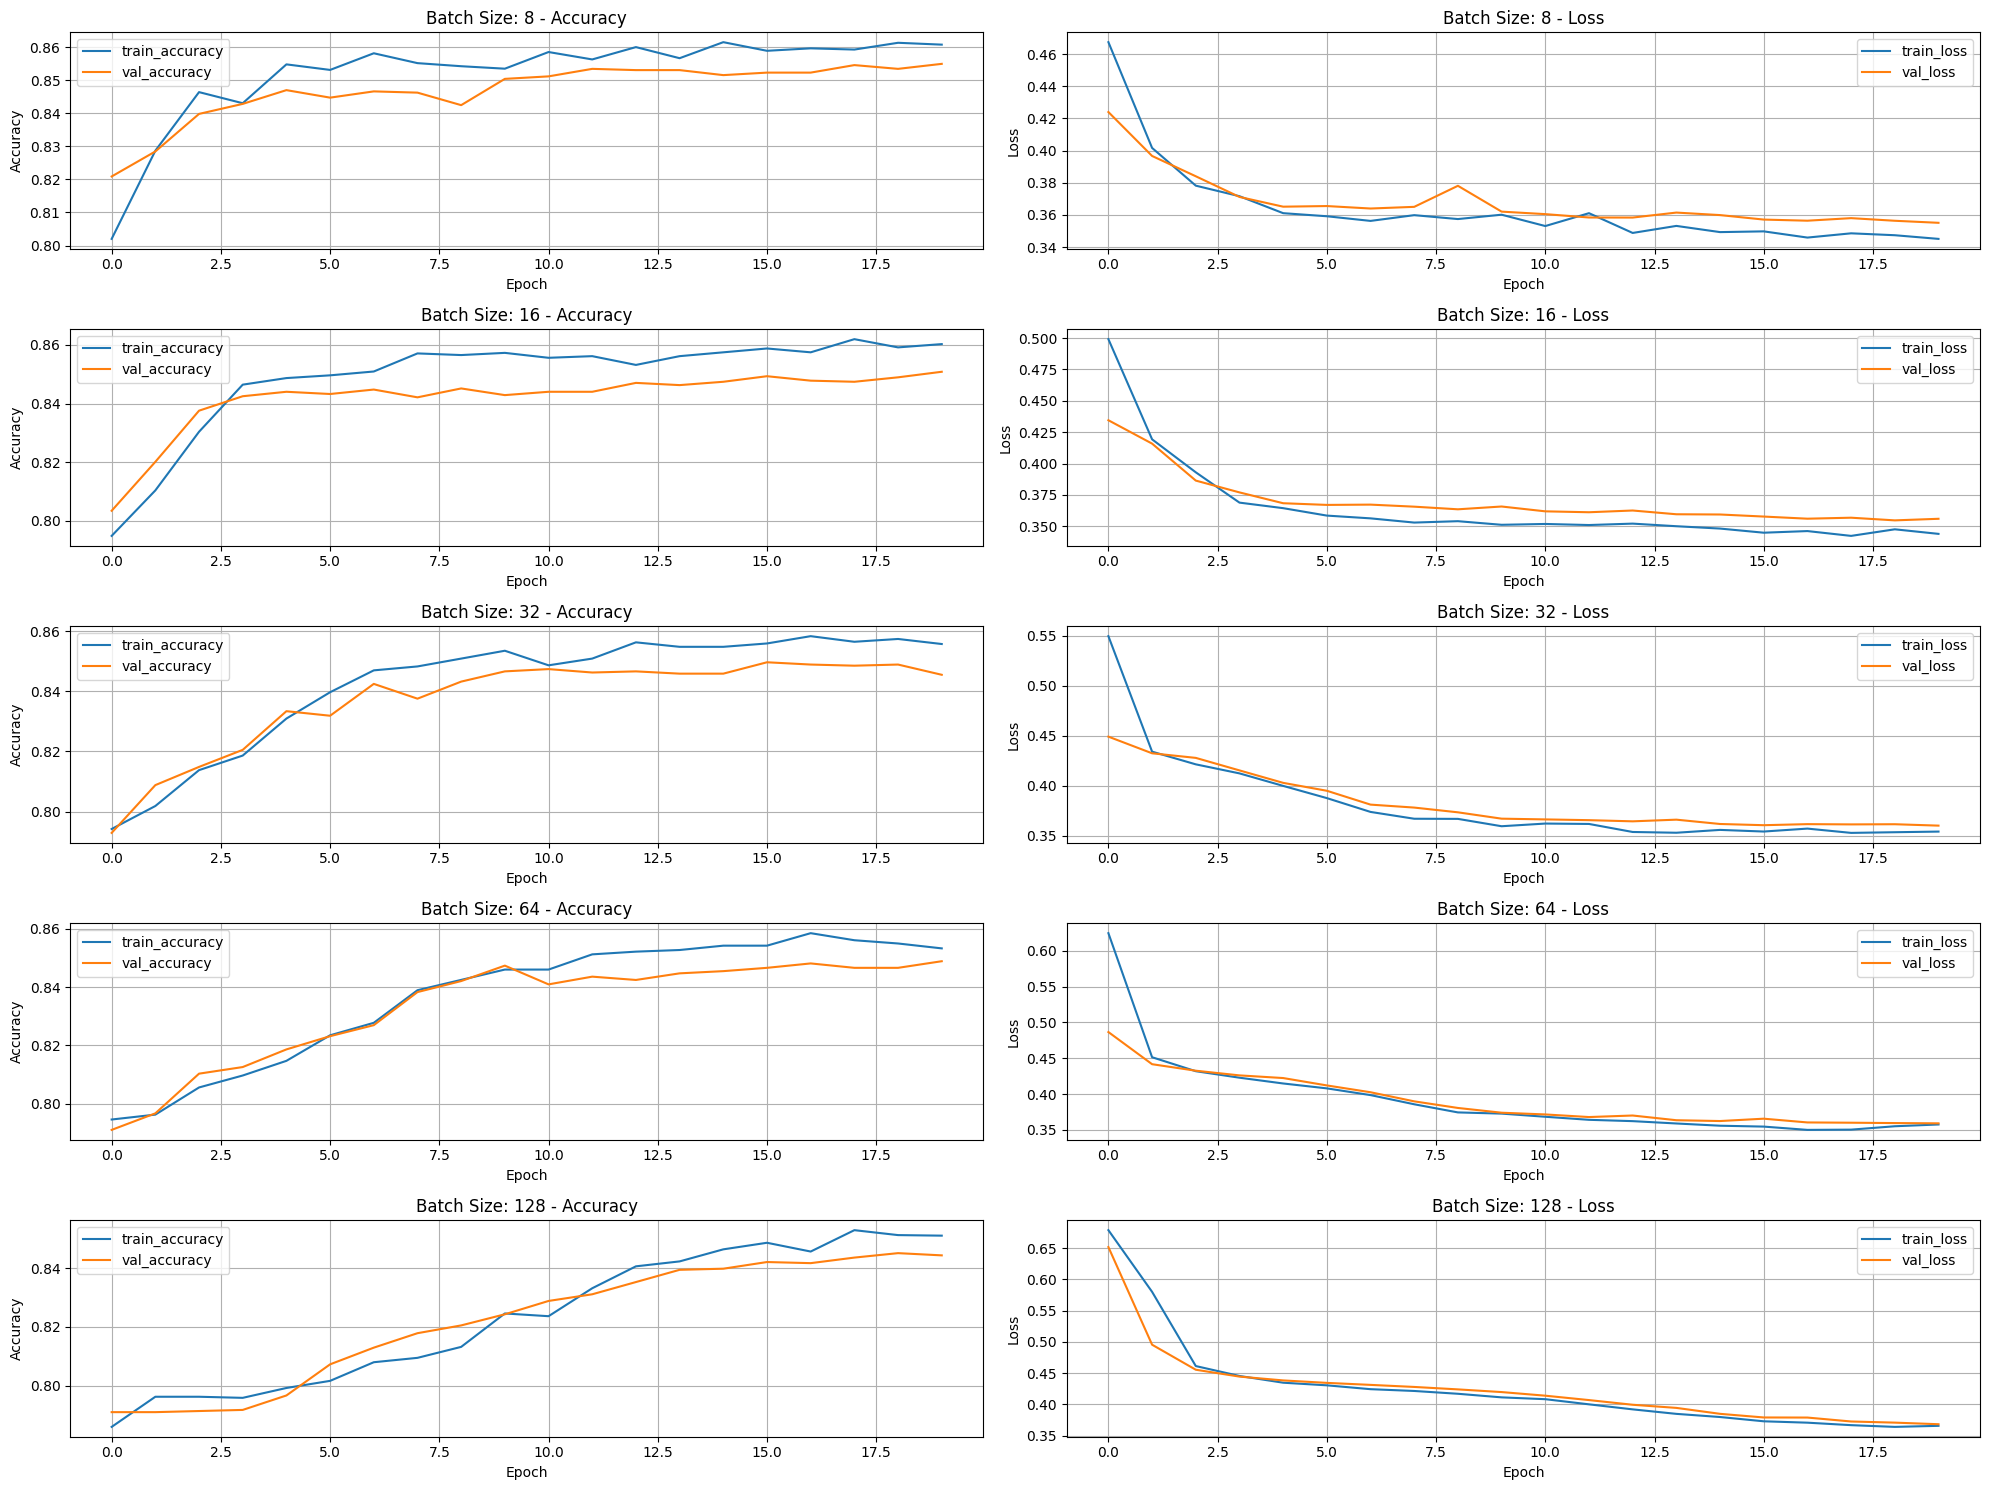

In [102]:
plt.figure(figsize=(20, 15))

for i, batch_size in enumerate(batch_sizes):
    history = histories_batch_size[batch_size]

    # Plot Accuracy
    plt.subplot(len(batch_sizes), 2, 2*i + 1)
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'Batch Size: {batch_size} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(len(batch_sizes), 2, 2*i + 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'Batch Size: {batch_size} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluation of Batch Size

*   **Batch Size 8:** The model shows fluctuating accuracy and loss, suggesting a less stable training process or potentially needing more epochs to converge properly due to the frequent updates.
*   **Batch Size 16:** Similar to batch size 8, there's still some fluctuation, but a clearer trend of improvement in accuracy and decrease in loss can be seen.
*   **Batch Size 32:** The training and validation curves appear smoother, indicating more stable updates. The model generally improves, but we need to check the final metrics.
*   **Batch Size 64:** This batch size generally shows good convergence and a relatively stable learning process, maintaining a good balance between training speed and model performance.
*   **Batch Size 128:** For this larger batch size, the curves are even smoother, and the model also converges well. Larger batch sizes usually offer faster training per epoch due to more efficient matrix operations.



In [104]:
batch_size_results = []

for batch_size in batch_sizes:
    history = histories_batch_size[batch_size]
    final_val_accuracy = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    batch_size_results.append({'Batch Size': batch_size, 'Validation Accuracy': final_val_accuracy, 'Validation Loss': final_val_loss})

results_df = pd.DataFrame(batch_size_results)
print("Batch Size Re-evaluation Results:")
print(results_df)


Batch Size Re-evaluation Results:
   Batch Size  Validation Accuracy  Validation Loss
0           8             0.854979         0.355137
1          16             0.850814         0.356031
2          32             0.845513         0.359879
3          64             0.848921         0.359165
4         128             0.844377         0.368288


## Task 9: Improve the Existing ANN



In [105]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LeakyReLU

# Optimal Parameters identified:
# Hidden Layers: 2
# Neurons per hidden layer: 16
# Activation Function: Leaky ReLU
# Optimizer: Adam
# Dropout Rate: 0.1
# Batch Size: 8
# Epochs: 50

# Initialize the ANN
final_model = Sequential()

# Input layer and first hidden layer with 16 neurons, Leaky ReLU activation, and 0.1 dropout
final_model.add(Dense(units=16, kernel_initializer='uniform', input_dim=X_train.shape[1]))
final_model.add(LeakyReLU(alpha=0.1))
final_model.add(Dropout(0.1))

# Second hidden layer with 16 neurons, Leaky ReLU activation, and 0.1 dropout
final_model.add(Dense(units=16, kernel_initializer='uniform'))
final_model.add(LeakyReLU(alpha=0.1))
final_model.add(Dropout(0.1))

# Output layer (1 unit, sigmoid activation for binary classification)
final_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compile the ANN with Adam optimizer, binary crossentropy loss, and accuracy metric
final_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the final model with optimal batch size and epochs
print("Training the final model with optimal parameters...")
final_history = final_model.fit(X_train, y_train, validation_split=0.33, batch_size=8, epochs=50, verbose=1)
print("Final model training complete.")

Training the final model with optimal parameters...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


670/670 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7977 - loss: 0.4714 - val_accuracy: 0.8088 - val_loss: 0.4337
Epoch 2/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8240 - loss: 0.4150 - val_accuracy: 0.8338 - val_loss: 0.4104
Epoch 3/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8408 - loss: 0.3873 - val_accuracy: 0.8406 - val_loss: 0.3833
Epoch 4/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8466 - loss: 0.3695 - val_accuracy: 0.8455 - val_loss: 0.3728
Epoch 5/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8520 - loss: 0.3622 - val_accuracy: 0.8455 - val_loss: 0.3749
Epoch 6/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8487 - loss: 0.3616 - val_accuracy: 0.8459 - val_loss: 0.3669
Epoch 7/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3580 - val_accuracy: 0.8459 - val_loss: 0.3636
Epoch 8/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8563 - loss: 0.3584 - val_accuracy: 0.8463 - val_

In [106]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Make predictions on the test set
y_pred_final = final_model.predict(X_test)
y_pred_final = (y_pred_final > 0.5)

# Evaluate the model
final_cm = confusion_matrix(y_test, y_pred_final)
final_acc = accuracy_score(y_test, y_pred_final)

print("Confusion Matrix (Final Model):")
print(final_cm)
print(f"Accuracy (Final Model): {final_acc:.4f}")
print("\nClassification Report (Final Model):")
print(classification_report(y_test, y_pred_final))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (Final Model):
[[1555   52]
 [ 222  171]]
Accuracy (Final Model): 0.8630

Classification Report (Final Model):
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.44      0.56       393

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



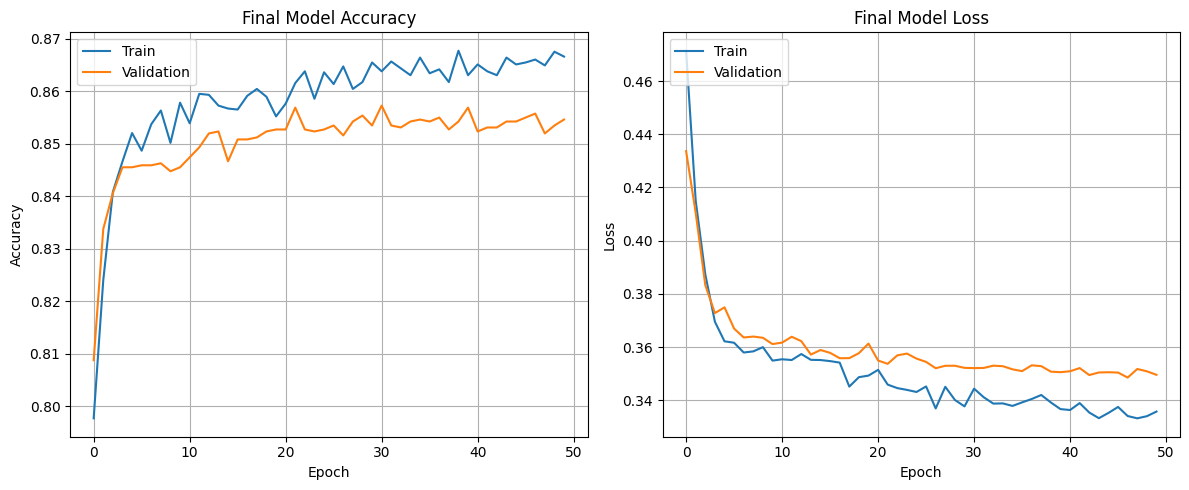

In [107]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_history.history['accuracy'])
plt.plot(final_history.history['val_accuracy'])
plt.title('Final Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(final_history.history['loss'])
plt.plot(final_history.history['val_loss'])
plt.title('Final Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [108]:
import os

# Define the path to save the model
model_save_path = 'final_churn_prediction_ann_model.h5'

# Save the model
final_model.save(model_save_path)
print(f"Final model saved to: {os.path.abspath(model_save_path)}")

Final model saved to: /content/final_churn_prediction_ann_model.h5
